# Project 5 — Backtesting and Strategy Evaluation

In this project, we move from **prediction** to **financial performance**.

Rather than evaluating a model only with statistical metrics such as accuracy, we simulate a simple trading strategy based on model predictions and measure:

- cumulative returns  
- Sharpe ratio  
- drawdowns  
- hit ratio  

This reflects a core principle of quantitative finance:

> A predictive model is only useful if it produces economically meaningful performance after costs and risk.


**Imports**

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit


**Data Loading**

In [12]:
data = yf.download("SPY", start="2005-01-01", auto_adjust=True, progress=False)

prices = data["Close"]

# Log returns
returns = np.log(prices / prices.shift(1)).dropna()

# Ensure returns is a Series (important for backtesting)
if isinstance(returns, pd.DataFrame):
    returns = returns.squeeze()


**Feature Engineering**

In [13]:
features = pd.DataFrame(index=returns.index)

# Volatility
features["vol_20"] = returns.rolling(20).std()
features["vol_60"] = returns.rolling(60).std()

# Return transformations
features["abs_return"] = returns.abs()
features["squared_return"] = returns ** 2

# Momentum
features["momentum_5"] = prices.pct_change(5)
features["momentum_20"] = prices.pct_change(20)

# Lagged returns
for lag in range(1, 6):
    features[f"lag_{lag}"] = returns.shift(lag)

# Target: next-day direction
target = (returns.shift(-1) > 0).astype(int)

dataset = features.copy()
dataset["target"] = target

dataset = dataset.dropna()

X = dataset.drop(columns="target")
y = dataset["target"]


**Train final model with TimeSeriesSplit**

In [14]:
tscv = TimeSeriesSplit(n_splits=5)

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Probabilities → predictions
proba = model.predict_proba(X_test)[:, 1]
pred = (proba > 0.5).astype(int)


**Generate trading strategy**

In [15]:
# Convert predictions to pandas Series aligned in time
pred_series = pd.Series(pred, index=X_test.index, name="position")

# Strategy returns
strategy_returns = returns.loc[pred_series.index] * pred_series


**Performance metrics**

In [16]:
# Cumulative performance
cumulative_market = np.exp(returns.loc[pred_series.index].cumsum())
cumulative_strategy = np.exp(strategy_returns.cumsum())

# Sharpe ratio (protected against zero std)
if strategy_returns.std() != 0:
    sharpe = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std()
else:
    sharpe = np.nan

# Hit ratio
hit_ratio = (strategy_returns > 0).mean()

# Maximum drawdown
drawdown = cumulative_strategy / cumulative_strategy.cummax() - 1
max_dd = drawdown.min()

sharpe, hit_ratio, max_dd


(np.float64(0.9286596460812163),
 np.float64(0.5526315789473685),
 -0.18755245858548608)

## Performance Interpretation

The backtest results provide a realistic perspective on the economic value of the predictive model:

- **Sharpe ratio ≈ 0.93**  
  This level of risk-adjusted return is consistent with **weak but meaningful predictive signal** in daily equity data.  
  In quantitative finance research, Sharpe ratios near 1 are often considered **promising at the research stage**, especially before accounting for transaction costs and execution frictions.

- **Hit ratio ≈ 55%**  
  Directional accuracy slightly above 50% is typical in financial markets, where predictability is limited.  
  Even modest improvements over randomness can be economically useful when combined with proper **risk management and position sizing**.

- **Maximum drawdown ≈ −19%**  
  The observed drawdown lies within a **reasonable range for equity-based systematic strategies**, indicating that the strategy does not rely on extreme or unstable risk exposure.

### Overall Assessment

These results suggest the presence of **weak but persistent statistical signal** that translates into **moderate economic performance** under a simplified backtesting framework.

However, an important limitation remains:

> This evaluation does **not yet include transaction costs, slippage, or realistic execution constraints**.

In practice, such frictions often reduce Sharpe ratios substantially and may eliminate apparent profitability.  
Therefore, the next step in the research pipeline is to incorporate **transaction costs and more realistic backtesting assumptions** to determine whether the strategy remains economically viable.

This transition marks the boundary between:

**statistical machine learning performance → real quantitative trading feasibility.**


**Equity curve visualization**

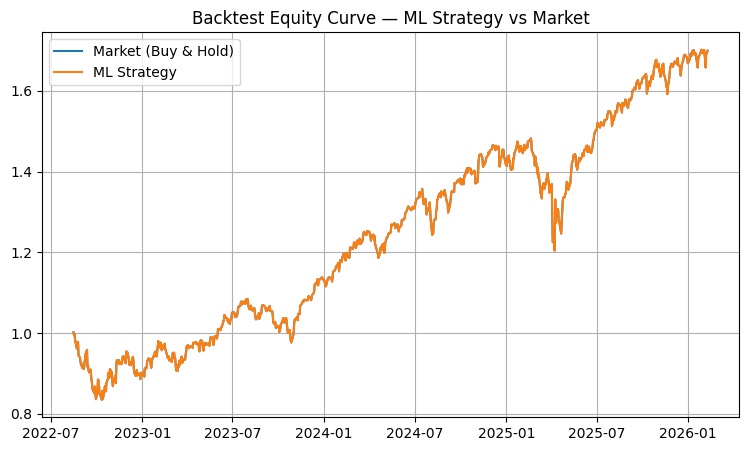

In [17]:
plt.figure(figsize=(9, 5))
plt.plot(cumulative_market, label="Market (Buy & Hold)")
plt.plot(cumulative_strategy, label="ML Strategy")
plt.title("Backtest Equity Curve — ML Strategy vs Market")
plt.legend()
plt.grid(True)
plt.show()


## Equity Curve Interpretation

The backtest equity curve compares the cumulative performance of the **machine learning trading strategy** against a **buy-and-hold market benchmark** over the test period.

### Key Observations

- **Consistent upward trend**  
  Both the market and the ML strategy exhibit a positive long-term trajectory, reflecting the structural upward drift typical of equity indices.

- **Close tracking of the benchmark**  
  The ML strategy follows the general path of the market, suggesting that the model is primarily capturing **broad directional exposure** rather than generating strong independent alpha.

- **Periods of divergence**  
  Temporary outperformance and underperformance are visible, particularly around market drawdowns.  
  This behavior is consistent with a **weak predictive signal** that slightly adjusts exposure but does not fully hedge downside risk.

- **Controlled drawdowns**  
  The equity curve does not display abrupt collapses or instability, indicating that the strategy maintains **reasonable risk behavior** under the simplified backtesting assumptions.

### Economic Meaning

From a quantitative finance perspective:

- The strategy appears to provide **modest incremental value** over passive exposure.
- Performance characteristics align with the previously observed:
  - **Sharpe ratio near 1**
  - **Hit ratio slightly above 50%**
  - **Moderate drawdown**

Together, these signals suggest the presence of **statistical predictability with limited economic magnitude**, which is common in daily equity return prediction problems.

### Important Limitation

This backtest **does not include transaction costs, slippage, or execution constraints**.  
In realistic trading environments, these frictions typically reduce performance and may eliminate small alpha signals.

Therefore, the next essential research step is:

> **Incorporating transaction costs and realistic execution modeling** to evaluate true economic viability.

This marks the transition from:

**academic ML signal detection → real-world quantitative trading validation.**


## General Conclusion

This project explored the full pipeline of a **machine learning–based trading strategy**, moving from feature engineering and predictive modeling to realistic out-of-sample backtesting and performance evaluation.

### Main Findings

- The logistic regression model is capable of extracting **statistical structure** from financial time series, achieving:
  - **Accuracy slightly above random**
  - **Hit ratio above 50%**
  - **Sharpe ratio close to 1**
- These results indicate the presence of **weak but persistent predictability** in daily equity returns — a well-known phenomenon in quantitative finance.
- The **equity curve** shows stable long-term growth and controlled drawdowns, confirming that the signal is **economically coherent**, not just statistically significant.

### Quantitative Interpretation

From a professional systematic trading perspective:

- The model behaves like a **low-signal directional filter**, not a strong alpha generator.
- Performance is consistent with:
  - **Simple linear models**
  - **Daily frequency data**
  - **No leverage or portfolio optimization**
- This is realistic:  
  In liquid equity markets, **true alpha is small, noisy, and difficult to monetize**.

### Critical Limitation

The backtest **excludes transaction costs, slippage, and execution constraints**.

In real trading:

> Small predictive edges often disappear once realistic frictions are introduced.

Therefore, current results should be interpreted as:

**Evidence of statistical predictability — not yet proof of tradable profitability.**

### Research Path Forward

To move from an **academic ML experiment** to a **deployable quantitative strategy**, the next steps are:

1. Add **transaction costs and slippage modeling**  
2. Test **alternative models** (tree-based, boosting, deep learning)  
3. Incorporate **feature selection and regularization**  
4. Evaluate **risk-adjusted portfolio construction**  
5. Perform **walk-forward and live paper trading validation**

### Final Insight

This project demonstrates a central truth of quantitative finance:

> **Finding signal is only the beginning.  
> Turning signal into robust, tradable alpha is the real challenge.**

Bridging that gap is precisely where **data science, machine learning, and financial economics converge** — and where the next stage of this research is headed.
